# About NETFLIX

Netflix is one of the most popular media and video streaming platforms. They have over 10000 movies or tv shows available on their platform, as of mid-2021, they have over 222M Subscribers globally. This tabular dataset consists of listings of all the movies and tv shows available on Netflix, along with details such as - cast, directors, ratings, release year, duration, etc.

# Business Problem

Analyze the data and generate insights that could help Netflix ijn deciding which type of shows/movies to produce and how they can grow the business in different countries

The dataset provided to you consists of a list of all the TV shows/movies available on Netflix:

* Show_id: Unique ID for every Movie / Tv Show
* Type: Identifier - A Movie or TV Show
* Title: Title of the Movie / Tv Show
* Director: Director of the Movie
* Cast: Actors involved in the movie/show
* Country: Country where the movie/show was produced
* Date_added: Date it was added on Netflix
* Release_year: Actual Release year of the movie/show
* Rating: TV Rating of the movie/show
* Duration: Total Duration - in minutes or number of seasons
* Listed_in: Genre
* Description: The summary description

In [1]:
#import the necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
#read the data

df = pd.read_csv(r"D:\Scaler\04 Data Analytics and Visualisation - Python Libraries\Business Case Study\01 Netflix\netflix.csv")

In [3]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
df.shape

(8807, 12)

In [5]:
df.dtypes

show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

In [6]:
df['release_year'].value_counts()

release_year
2018    1147
2017    1032
2019    1030
2020     953
2016     902
        ... 
1959       1
1925       1
1961       1
1947       1
1966       1
Name: count, Length: 74, dtype: int64

In [7]:
df['type'].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [8]:
df['country'].value_counts()

country
United States                             2818
India                                      972
United Kingdom                             419
Japan                                      245
South Korea                                199
                                          ... 
Romania, Bulgaria, Hungary                   1
Uruguay, Guatemala                           1
France, Senegal, Belgium                     1
Mexico, United States, Spain, Colombia       1
United Arab Emirates, Jordan                 1
Name: count, Length: 748, dtype: int64

In [9]:
# Number of titles added by year

df['date_added'] = pd.to_datetime(df['date_added'],errors='coerce')
df['year_added'] = df['date_added'].dt.year
titles_by_year = df['year_added'].value_counts().sort_index()
print("\nNumber of Titles Added by Year:")
print(titles_by_year)


Number of Titles Added by Year:
year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      10
2014.0      23
2015.0      73
2016.0     418
2017.0    1164
2018.0    1625
2019.0    1999
2020.0    1878
2021.0    1498
Name: count, dtype: int64


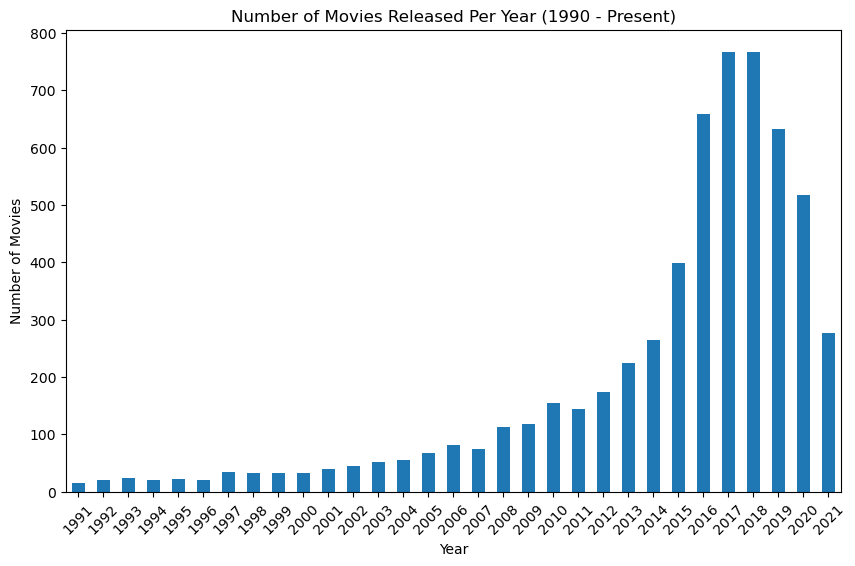

In [10]:
# How has the number of movies released per year changed over the last 20-30 years?

movies_df = df[df['type']=='Movie']

movies_last_30_years = movies_df[movies_df['release_year']>1990]

movies_per_year = movies_last_30_years['release_year'].value_counts().sort_index()

plt.figure(figsize=(10,6))
movies_per_year.plot(kind='bar')
plt.title('Number of Movies Released Per Year (1990 - Present)')
plt.xlabel('Year')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45)
plt.show()

In [11]:
# Number of Movies vs. TV Shows

type_count = df['type'].value_counts()
print('Number of Movies vs TV shows:')
print(type_count)

Number of Movies vs TV shows:
type
Movie      6131
TV Show    2676
Name: count, dtype: int64


In [12]:
# Rating Count

rating_count = df['rating'].value_counts()
print('Number of Rating in Movies and TV shows:')
print(rating_count)

Number of Rating in Movies and TV shows:
rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64


In [13]:
# Rating Count for Movies

rating_count_movies = df[df['type']=='Movie']
rating_movies = rating_count_movies['rating'].value_counts()
print('Number of Rating in Movies:')
print(rating_movies)

Number of Rating in Movies:
rating
TV-MA       2062
TV-14       1427
R            797
TV-PG        540
PG-13        490
PG           287
TV-Y7        139
TV-Y         131
TV-G         126
NR            75
G             41
TV-Y7-FV       5
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64


In [14]:
# Rating Count for TV Show

rating_count_shows = df[df['type']=='TV Show']
rating_shows = rating_count_shows['rating'].value_counts()
print('Number of Rating in TV Shows:')
print(rating_shows)

Number of Rating in TV Shows:
rating
TV-MA       1145
TV-14        733
TV-PG        323
TV-Y7        195
TV-Y         176
TV-G          94
NR             5
R              2
TV-Y7-FV       1
Name: count, dtype: int64


In [15]:
# What is the best time to launch a TV show
tv_shows_df = df[df['type']=='TV Show']

tv_shows_df['date_added'] = pd.to_datetime(tv_shows_df['date_added'],errors='coerce')

tv_shows_df['month_added'] = tv_shows_df['date_added'].dt.month
tv_shows_df['year_added'] = tv_shows_df['date_added'].dt.year

tv_shows_by_month_total = tv_shows_df['month_added'].value_counts().sort_index()

tv_shows_by_average_total = tv_shows_df.groupby('month_added').size().mean()

print('Total number of TV shows added per month')
print(tv_shows_by_month_total)

print('\nAverage number of TV shows added per month:')
print(tv_shows_by_average_total)

Total number of TV shows added per month
month_added
1.0     181
2.0     175
3.0     205
4.0     209
5.0     187
6.0     232
7.0     254
8.0     230
9.0     246
10.0    210
11.0    199
12.0    250
Name: count, dtype: int64

Average number of TV shows added per month:
214.83333333333334


In [16]:
# Analysis of directors of different types of shows/movies

tv_shows_with_dir = tv_shows_df.dropna(subset='director')
movies_shows_with_dir = movies_df.dropna(subset='director')

top_movie_directors = movies_shows_with_dir['director'].value_counts().head(10)
print('Top 10 Directors for Movies:')
print(top_movie_directors)

top_tv_shows_directors = tv_shows_with_dir['director'].value_counts().head(10)
print('\nTop 10 Directors for TV Shows:')
print(top_tv_shows_directors)

Top 10 Directors for Movies:
director
Rajiv Chilaka             19
Raúl Campos, Jan Suter    18
Suhas Kadav               16
Marcus Raboy              15
Jay Karas                 14
Cathy Garcia-Molina       13
Martin Scorsese           12
Youssef Chahine           12
Jay Chapman               12
Steven Spielberg          11
Name: count, dtype: int64

Top 10 Directors for TV Shows:
director
Alastair Fothergill    3
Rob Seidenglanz        2
Hsu Fu-chun            2
Iginio Straffi         2
Shin Won-ho            2
Ken Burns              2
Stan Lathan            2
Thomas Astruc          1
Quek Shio-chuan        1
Elías León             1
Name: count, dtype: int64


In [17]:
# Analysis of directors of different types of shows/movies

tv_shows_with_cast = tv_shows_df.dropna(subset='cast')
movies_shows_with_cast = movies_df.dropna(subset='cast')

movie_actors = movies_shows_with_cast['cast'].str.split(', ').explode()
top_movie_cast = movie_actors.value_counts().head(10)
print('Top 10 Cast for Movies:')
print(top_movie_cast)

tv_actors = tv_shows_with_cast['cast'].str.split(', ').explode()
top_tv_cast = tv_actors.value_counts().head(10)
print('\nTop 10 Cast for TV Shows:')
print(top_tv_cast)

Top 10 Cast for Movies:
cast
Anupam Kher         42
Shah Rukh Khan      35
Naseeruddin Shah    32
Akshay Kumar        30
Om Puri             30
Amitabh Bachchan    28
Julie Tejwani       28
Paresh Rawal        28
Rupa Bhimani        27
Boman Irani         27
Name: count, dtype: int64

Top 10 Cast for TV Shows:
cast
Takahiro Sakurai      25
Yuki Kaji             19
Daisuke Ono           17
Junichi Suwabe        17
Ai Kayano             17
Yuichi Nakamura       16
Jun Fukuyama          15
Yoshimasa Hosoya      15
David Attenborough    14
Mamoru Miyano         13
Name: count, dtype: int64


In [18]:
# Does Netflix has more focus on TV Shows than movies in recent years

recent_years = 5

recent_df = df[df['year_added']>=df['year_added'].max() - recent_years]

tv_shows_vs_movies = recent_df.groupby(['year_added','type']).size().unstack()

tv_shows_vs_movies = tv_shows_vs_movies.fillna(0)

print(tv_shows_vs_movies)

total_tv_shows = tv_shows_vs_movies['TV Show'].sum()
total_movies = tv_shows_vs_movies['Movie'].sum()

print(f"\nTotal Movies added in the last {recent_years} years: {total_movies}")
print(f"Total TV Shows added in the last {recent_years} years: {total_tv_shows}")

if total_tv_shows > total_movies:
    print(f"\nNetflix has focused more on TV Shows than Movies in the last {recent_years} years.")
else:
    print(f"\nNetflix has focused more on Movies than TV Shows in the last {recent_years} years.")

type        Movie  TV Show
year_added                
2016.0        253      165
2017.0        839      325
2018.0       1237      388
2019.0       1424      575
2020.0       1284      594
2021.0        993      505

Total Movies added in the last 5 years: 6030
Total TV Shows added in the last 5 years: 2552

Netflix has focused more on Movies than TV Shows in the last 5 years.


In [19]:
# Understanding what content is available in different countries

df_clean = df.dropna(subset='country')

df_clean['country'] = df['country'].str.split(', ')
df_exploded = df_clean.explode('country')


content_by_country = df_exploded['country'].value_counts()

print('Top 10 Content available by country:')
print(content_by_country.head(10))

Top 10 Content available by country:
country
United States     3689
India             1046
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64


In [20]:
# Analyzing Content Type (Movies vs. TV Shows) by Country

content_type_by_country = df_exploded.groupby(['country','type']).size().unstack(fill_value=0)

print("\nTop 10 Distribution of content types (Movies vs TV Shows) by country:")
print(content_type_by_country.head(10))


Top 10 Distribution of content types (Movies vs TV Shows) by country:
type         Movie  TV Show
country                    
                 1        1
Afghanistan      1        0
Albania          1        0
Algeria          3        0
Angola           1        0
Argentina       71       20
Armenia          1        0
Australia       94       66
Austria         11        1
Azerbaijan       0        1


In [21]:
# Genre Distribution by Country

df_exploded['listed_in'] = df_exploded['listed_in'].str.split(', ')
df_genre_exploded = df_exploded.explode('listed_in')

genres_by_country = df_genre_exploded.groupby(['country','listed_in']).size().unstack(fill_value=0)

print("\nTop 10 Genre distribution by country (Top 10):")
print(genres_by_country.head(10))


Top 10 Genre distribution by country (Top 10):
listed_in    Action & Adventure  Anime Features  Anime Series  \
country                                                         
                              0               0             0   
Afghanistan                   0               0             0   
Albania                       0               0             0   
Algeria                       0               0             0   
Angola                        1               0             0   
Argentina                     3               0             0   
Armenia                       0               0             0   
Australia                    13               0             1   
Austria                       0               0             0   
Azerbaijan                    0               0             0   

listed_in    British TV Shows  Children & Family Movies  Classic & Cult TV  \
country                                                                      
               

In [22]:
# Top Content in Each Country

top_content_by_country = df_exploded.groupby(['country','title']).size().sort_values(ascending=False)

print('\nTop 10 content available in different countries')
print(top_content_by_country)


Top 10 content available in different countries
country        title                                    
               D.P.                                         1
United States  Benji's Very Own Christmas Story             1
               Bella and the Bulldogs                       1
               Ben 10                                       1
               Ben Platt Live from Radio City Music Hall    1
                                                           ..
Israel         A Tale of Love and Darkness                  1
               Black Space                                  1
               Bobbi Jene                                   1
               Brave Miss World                             1
Zimbabwe       Trophy                                       1
Length: 10014, dtype: int64


## 1. Defining Problem Statement and Analysing basic metrics

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   object        
 1   type          8807 non-null   object        
 2   title         8807 non-null   object        
 3   director      6173 non-null   object        
 4   cast          7982 non-null   object        
 5   country       7976 non-null   object        
 6   date_added    8709 non-null   datetime64[ns]
 7   release_year  8807 non-null   int64         
 8   rating        8803 non-null   object        
 9   duration      8804 non-null   object        
 10  listed_in     8807 non-null   object        
 11  description   8807 non-null   object        
 12  year_added    8709 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(10)
memory usage: 894.6+ KB


In [24]:
# Extract duration and differentiate between minutes and seasons

df['duration_type'] = df['duration'].apply(lambda x: 'Seasons' if isinstance(x,str) and 'Season' in x else 'Minutes')
df['duration_num'] = df['duration'].str.extract('(\d+)').astype(float)
duration_stats = df.groupby('duration_type')['duration_num'].describe()
print("\nDuration Statistics:")
print(duration_stats)


Duration Statistics:
                count       mean        std  min   25%   50%    75%    max
duration_type                                                             
Minutes        6128.0  99.577187  28.290593  3.0  87.0  98.0  114.0  312.0
Seasons        2676.0   1.764948   1.582752  1.0   1.0   1.0    2.0   17.0


## 2. Observations on the shape of data, data types of all the attributes, conversion of categorical attributes to 'category' (If required), missing value detection, statistical summary

In [25]:
# shape of the data

df.shape

(8807, 15)

In [26]:
# data types of all the attributes

df.dtypes

show_id                  object
type                     object
title                    object
director                 object
cast                     object
country                  object
date_added       datetime64[ns]
release_year              int64
rating                   object
duration                 object
listed_in                object
description              object
year_added              float64
duration_type            object
duration_num            float64
dtype: object

In [27]:
# statistical summary

df.describe().T

,count,mean,min,25%,50%,75%,max,std
date_added,8709,2019-05-23 01:45:29.452290816,2008-01-01 00:00:00,2018-04-20 00:00:00,2019-07-12 00:00:00,2020-08-26 00:00:00,2021-09-25 00:00:00,NaN
release_year,8807.0,2014.180198,1925.0,2013.0,2017.0,2019.0,2021.0,8.819312
year_added,8709.0,2018.887932,2008.0,2018.0,2019.0,2020.0,2021.0,1.567961
duration_num,8804.0,69.846888,1.0,2.0,88.0,106.0,312.0,50.814828


## 3. Non-Graphical Analysis: Value counts and unique attributes

In [28]:
# Split the 'listed_in' column and count the frequency of each genre

genres = df['listed_in'].str.split(', ').explode()
genre_count = genres.value_counts().head(20)
print("\nTop 20 Most Common Genres:")
print(genre_count)


Top 20 Most Common Genres:
listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
TV Comedies                  581
Thrillers                    577
Crime TV Shows               470
Kids' TV                     451
Docuseries                   395
Music & Musicals             375
Romantic TV Shows            370
Horror Movies                357
Stand-Up Comedy              343
Reality TV                   255
Name: count, dtype: int64


In [29]:
# Value Counts for Categorical Columns

categorical_columns = ['type', 'country', 'rating', 'listed_in']

for column in categorical_columns:
    print(f"\nValue counts for '{column}':")
    print(df[column].value_counts())


Value counts for 'type':
type
Movie      6131
TV Show    2676
Name: count, dtype: int64

Value counts for 'country':
country
United States                             2818
India                                      972
United Kingdom                             419
Japan                                      245
South Korea                                199
                                          ... 
Romania, Bulgaria, Hungary                   1
Uruguay, Guatemala                           1
France, Senegal, Belgium                     1
Mexico, United States, Spain, Colombia       1
United Arab Emirates, Jordan                 1
Name: count, Length: 748, dtype: int64

Value counts for 'rating':
rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min     

In [30]:
# Finding Unique Attributes for All Columns

print('\nNumber of unique values in each column:')
print(df.nunique())


Number of unique values in each column:
show_id          8807
type                2
title            8807
director         4528
cast             7692
country           748
date_added       1699
release_year       74
rating             17
duration          220
listed_in         514
description      8775
year_added         14
duration_type       2
duration_num      210
dtype: int64


## 4. Visual Analysis - Univariate, Bivariate after pre-processing of the data

In [31]:
df.isnull().sum()

show_id             0
type                0
title               0
director         2634
cast              825
country           831
date_added         98
release_year        0
rating              4
duration            3
listed_in           0
description         0
year_added         98
duration_type       0
duration_num        3
dtype: int64

In [32]:
df['country'] = df['country'].astype(str).str.split(', ')
df['cast'] = df['cast'].astype(str).str.split(', ')
df['director'] = df['director'].astype(str).str.split(', ')


df_exploded = df.explode('country')
df_exploded = df_exploded.explode('cast')
df_exploded = df_exploded.explode('director')

df_exploded = df_exploded.drop_duplicates()

In [33]:
df.isnull().sum()

show_id           0
type              0
title             0
director          0
cast              0
country           0
date_added       98
release_year      0
rating            4
duration          3
listed_in         0
description       0
year_added       98
duration_type     0
duration_num      3
dtype: int64

#### **Note**
- During the Pre-Processing the missing values are treated, and there are still few more missing values, it will be treated in the upcoming tasks.

### 4.1 For continuous variable(s): Distplot, countplot, histogram for univariate analysis

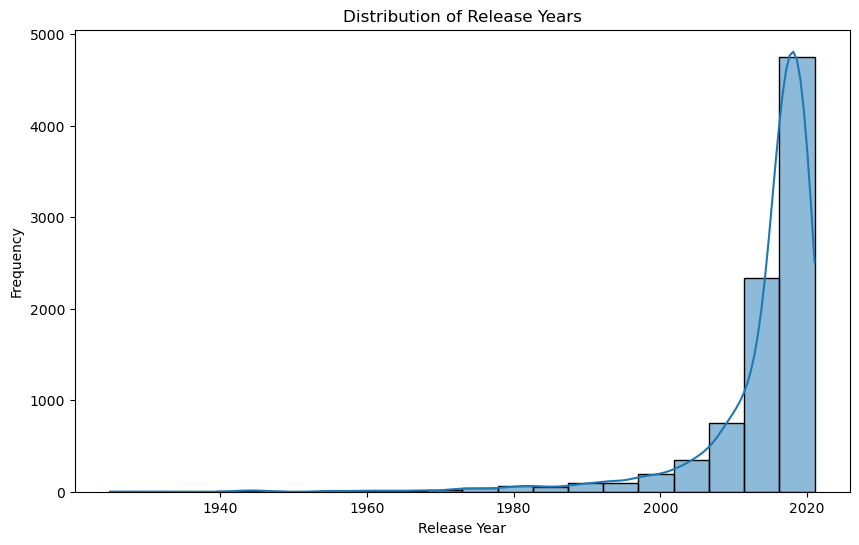

In [34]:
#Distribution of release years

plt.figure(figsize=(10,6))
sns.histplot(df['release_year'],kde=True,bins=20)
plt.title('Distribution of Release Years')
plt.xlabel('Release Year')
plt.ylabel('Frequency')
plt.show()

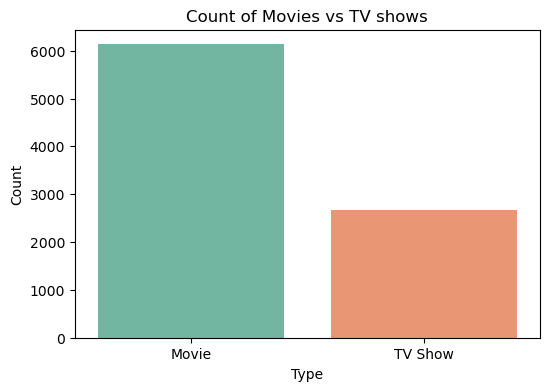

In [35]:
# countplot for Type

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='type',palette='Set2')
plt.title('Count of Movies vs TV shows')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()

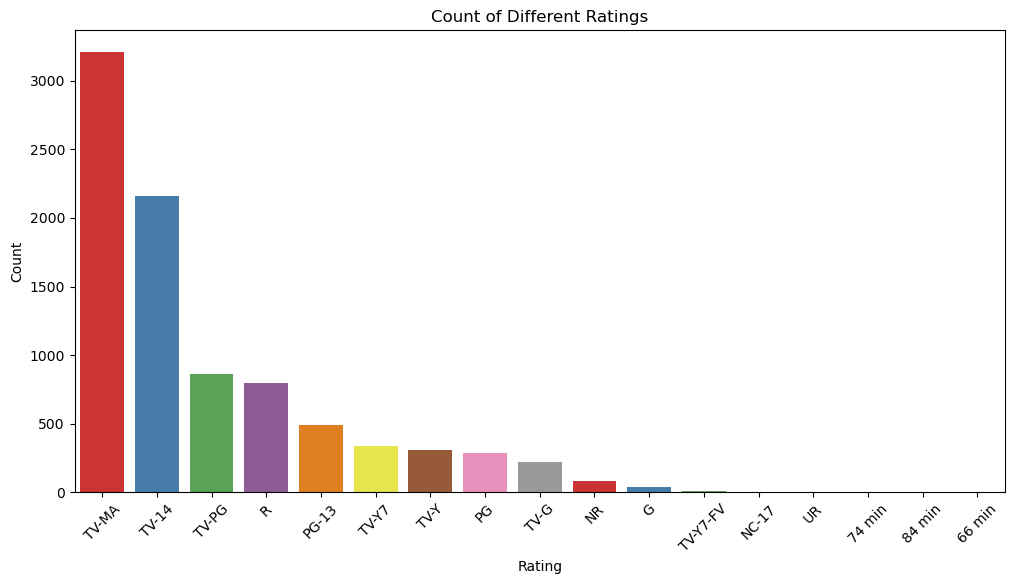

In [36]:
# Countplot for Rating

plt.figure(figsize=(12,6))
sns.countplot(data=df,x='rating',order=df['rating'].value_counts().index, palette='Set1')
plt.title('Count of Different Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

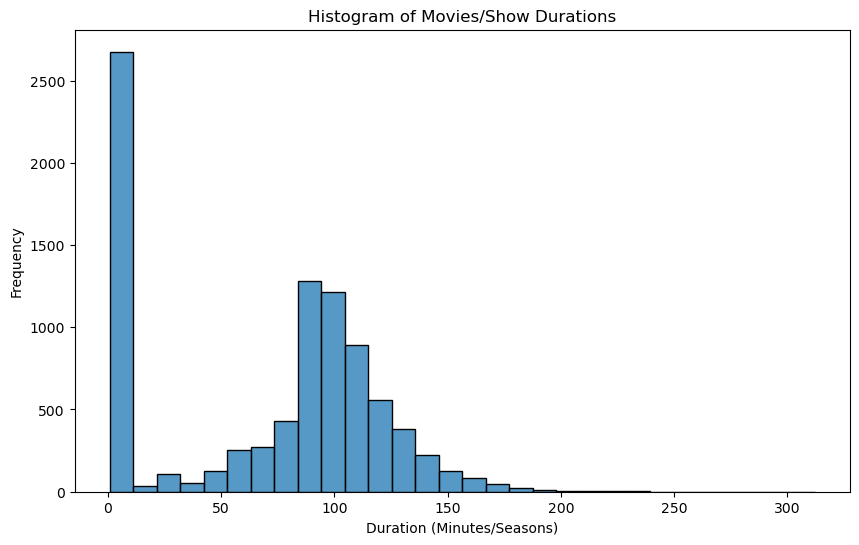

In [37]:
# Histogram for Duration

plt.figure(figsize=(10,6))
df['duration_num'] = df['duration'].str.extract('(\d+)').astype(float)
sns.histplot(df['duration_num'],kde=False,bins=30)
plt.title('Histogram of Movies/Show Durations')
plt.xlabel('Duration (Minutes/Seasons)')
plt.ylabel('Frequency')
plt.show()

### 4.2 For categorical variable(s): Boxplot

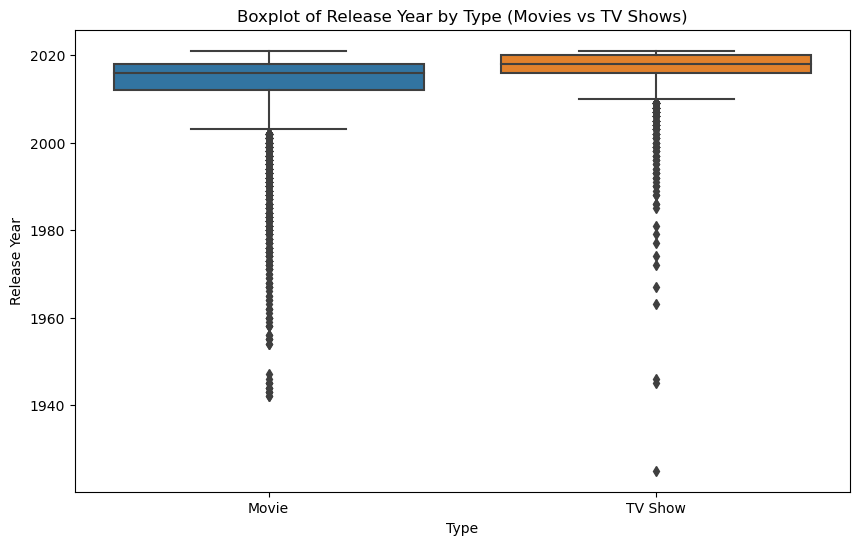

In [38]:
#boxplot of release year by type (Movies vs TV Shows)

plt.figure(figsize=(10,6))
sns.boxplot(x='type',y='release_year',data=df)
plt.title('Boxplot of Release Year by Type (Movies vs TV Shows)')
plt.xlabel('Type')
plt.ylabel('Release Year')
plt.show()

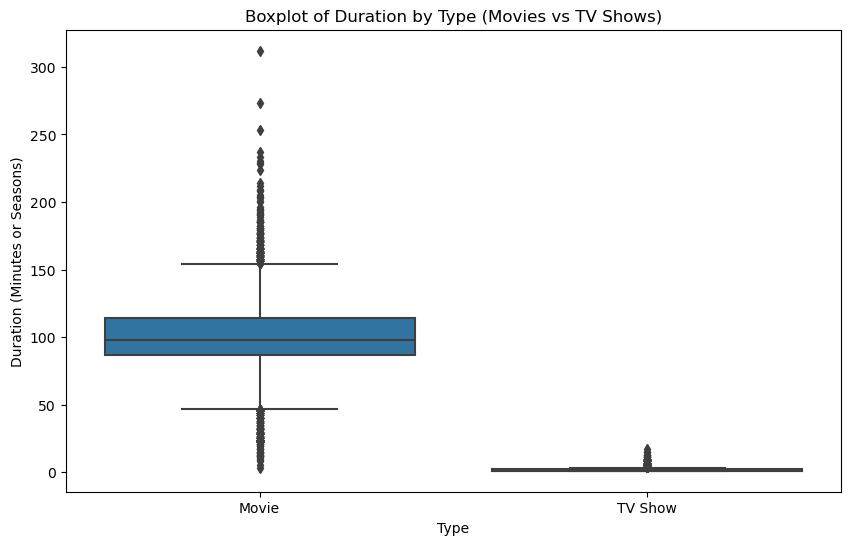

In [39]:
#boxplot of duration by type (Movies vs TV Shows)

df['duration_num'] = df['duration'].str.extract('(\d+)').astype(float)

plt.figure(figsize=(10,6))
sns.boxplot(x='type',y='duration_num',data=df)
plt.title('Boxplot of Duration by Type (Movies vs TV Shows)')
plt.xlabel('Type')
plt.ylabel('Duration (Minutes or Seasons)')
plt.show()

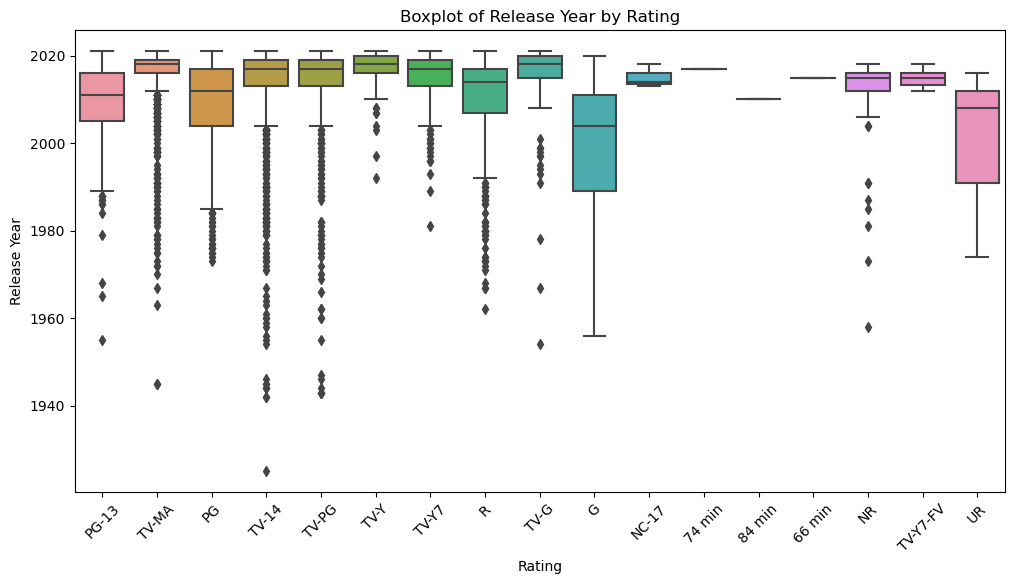

In [40]:
#boxplot of release year by rating

plt.figure(figsize=(12,6))
sns.boxplot(x='rating',y='release_year',data=df)
plt.title('Boxplot of Release Year by Rating')
plt.xlabel('Rating')
plt.ylabel('Release Year')
plt.xticks(rotation=45)
plt.show()

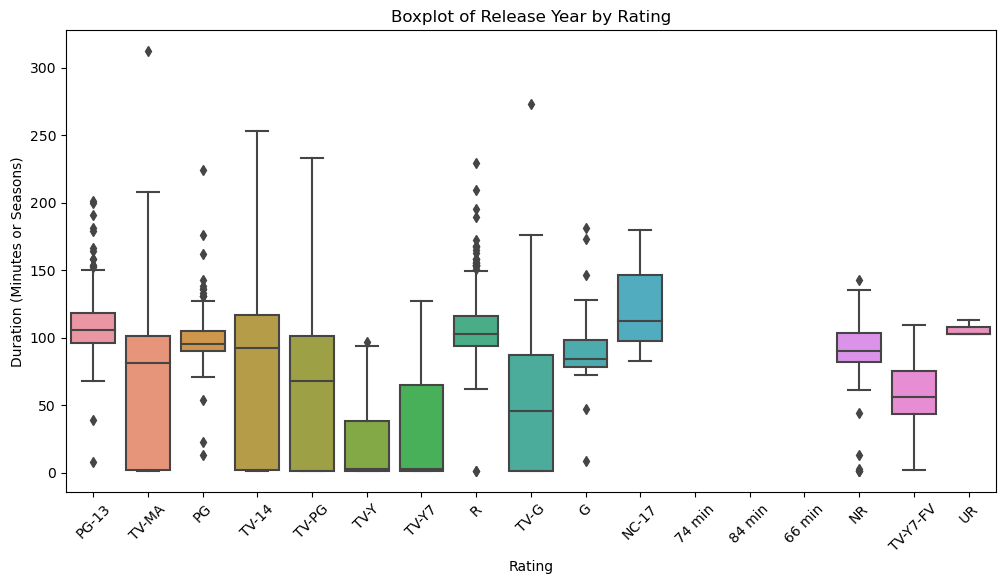

In [41]:
#boxplot of duration by rating

plt.figure(figsize=(12,6))
sns.boxplot(x='rating',y='duration_num',data=df)
plt.title('Boxplot of Release Year by Rating')
plt.xlabel('Rating')
plt.ylabel('Duration (Minutes or Seasons)')
plt.xticks(rotation=45)
plt.show()

### 4.3 For correlation: Heatmaps, Pairplots

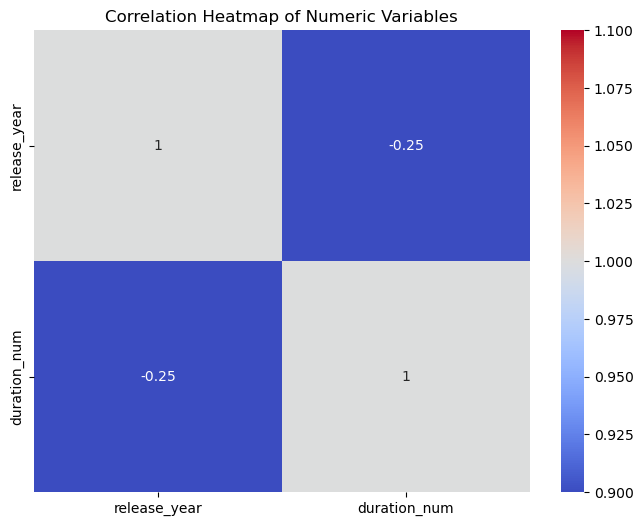

In [42]:
# Heatmap for Correlation

numeric_columns = ['release_year', 'duration_num']

corr_matrix = df[numeric_columns].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=1, vmax=1)
plt.title('Correlation Heatmap of Numeric Variables')
plt.show()

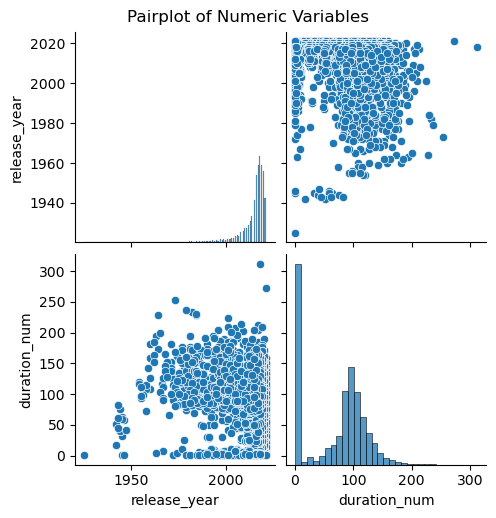

In [43]:
# Pairplot 

sns.pairplot(df[numeric_columns])
plt.suptitle('Pairplot of Numeric Variables',y=1.02)
plt.show()

## 5. Missing Value & Outlier check (Treatment optional)

In [44]:
# checcking for missing values

missing_values = df.isnull().sum()

print('Missing value in each column:')
print(missing_values[missing_values>0])

Missing value in each column:
date_added      98
rating           4
duration         3
year_added      98
duration_num     3
dtype: int64


In [45]:
df['director'].fillna('unknown',inplace=True)

In [46]:
df.isnull().sum()

show_id           0
type              0
title             0
director          0
cast              0
country           0
date_added       98
release_year      0
rating            4
duration          3
listed_in         0
description       0
year_added       98
duration_type     0
duration_num      3
dtype: int64

In [47]:
# create a function to detect outliers by IQR method

def outliers(df):
    q1 = np.percentile(df,25)
    q3 = np.percentile(df,75)

    IQR = q3 - q1

    lower_bound = q1 - 1.5 * IQR
    upper_bound = q3 + 1.5 * IQR

    return df[(df < lower_bound) | (df > upper_bound)]

In [48]:
# check for outliers in numeric columns

outliers_release_year = outliers(df['release_year'])
outliers_duration = outliers(df['duration_num'])

print('Outliers in Release Year:')
print(outliers_release_year)
print('\nOutliers in Duration:')
print(outliers_duration)

Outliers in Release Year:
7       1993
22      1996
24      1998
26      1997
41      1975
        ... 
8764    1994
8766    2002
8768    2001
8770    2001
8792    1973
Name: release_year, Length: 719, dtype: int64

Outliers in Duration:
Series([], Name: duration_num, dtype: float64)


In [49]:
#removing outliers

df_new = df[~df['duration_num'].isin(outliers_duration)]
df_new = df[~df['release_year'].isin(outliers_release_year)]

In [50]:
df_new.shape

(8088, 15)

In [51]:
df.shape

(8807, 15)

In [52]:
len(df) - len(df_new)

719

#### **Note**
- After Data Pre Processing and handling the Missing Values, There are 719 Outliers in total

## 6. Insights based on Non-Graphical and Visual Analysis

### 6.1 Comments on the range of attributes

1. Release Year
    - Netflix focuses on newer titles, as evidenced by the majority of its content being released after the year 2000. Older titles could be purchased licenses or classics.

2. Duration
    - Movies and TV series have different running times. While TV series with multiple seasons are the exception when it comes to content length, movies typically have set running times.

3. Type
    - While Netflix continues to have a wider selection of movies, the rise in TV shows indicates a growing emphasis on serialized programming to hold viewers' attention for extended periods of time.

4. Rating
    - Netflix appears to target a younger and more adult audience, as evidenced by the significant amount of programming labeled TV-MA and TV-14

5. Country
    - Although Netflix content is highly diverse, with a focus on multiple countries, its most movies and TV shows countries are from United States and India.

6. Genre
    - Although Netflix offers a wide range of content, its most popular genres are International Movies and dramas, indicating that the company prioritizes content that appeals to a broad audience.

7. Cast and Directors
    - Netflix seems to work with a variety of well-known filmmakers and worldwide stars, utilizing well-known performers to draw in viewers from around the world. 
    - Top Directors for Movies Rajiv Chilaka, Raúl Campos, Jan Suter
    - Top Directors for TV Shows Alastair Fothergill, Rob Seidenglanz
    - Top Cast for Movies Anupam Kher, Shah Rukh Khan
    - Top Cast for TV Shows Takahiro Sakurai, Yuki Kaji

8. Date Added
    - Netflix has been steadily adding new material, particularly in the last several years. Peak months for content additions may coincide with strong streaming months in summer(July) and Christmas(December)

9. Missing Values
    - Missing values in the director, country and cast columns could mean that getting metadata is difficult, particularly for foreign or older content.

10. Outliers
    - The presence of outliers reflects the broad diversity of content on Netflix, ranging from short films to multi-season series and classic films from earlier decades.

#### 6.2 Comments on the distribution of the variables and relationship between them

1. Distribution of Key Variable
    - Release Year Distribution
        - The skew towards recent years indicates Netflix's focus on modern content, with only a small number of classics or older films in the catalog.
    - Duration Distribution
        - The duration of most movies follows industry standards. There aren't many TV shows with several seasons, which suggests Netflix is concentrating on creating shorter TV episodes.
    - Rating Distribution
        - The platform caters primarily to adult and teenage audiences, with relatively fewer titles aimed at younger viewers.
    - Genre Distribution - Listed_in:
        - The most popular genres are comedies and dramas, which reflects their broad popularity and strong demand across many demographics.
    - Country Distribution
        - Netflix is a global platform, but its library is dominated by content from the United States and a few other major markets, suggesting a strong foothold in these regions.

2. Relationship Between Key Variables
    - Relationship Between Release Year and Type (Movie vs TV Show)
        - Netflix has seen a considerable increase in TV series, particularly in the previous five to ten years, which is consistent with their emphasis on creating serialized entertainment.
    - Relationship Between Duration and Type
        - The lengths of TV series (measured in seasons) and movies (measured in minutes) varies noticeably, demonstrating the diversity of content available on the platform.
    - Relationship Between Country and Genre
        - Different countries have varying strengths in content production, reflecting regional preferences.
    - Relationship Between Rating and Type
        - TV shows on Netflix tend to target older audiences, with many shows catering to mature viewers. Movies, on the other hand, have a more varied audience based on ratings.
    - Relationship Between Rating and Duration
        - The duration of content tends to increase for more mature content, possibly due to the complexity of storytelling or audience demand for longer engagement.

#### 6.3 Comments for each univariate and bivariate plot

1. Univariate Analysis Comments
    - Distribution of Release Year
        - The distribution of release years reveals that material increased sharply starting in the 2000s and peaked in the 2017s. This suggests that Netflix prioritizes fresher content.
    - Distribution of Duration
        - The running time of movies is distributed rather normally, with the majority lying between 90 and 120 minutes. Long feature films and shorter ones are exceptions.
    - Distribution of Rating
        - The TV-MA rating dominates, followed by TV-14 and TV-PG. This suggests Netflix's content largely targets mature and young adult audiences. 
    - Distribution of Genre (Listed_in)
        - The genres are diverse, but Dramas and International Movies appear most frequently, reflecting their universal appeal.
    - Distribution of Country
        - The USA leads in content production, followed by India and the UK. This shows Netflix’s reliance on these countries for content creation.

2. Bivariate Analysis Comments
    - Release Years vs Type
        - Compared to movies, TV series have grown significantly in recent years. Even though movies still make dominate overall content, the growing trend in TV shows indicates Netflix is putting more of an emphasis on serialized programming.
    - Rating vs Type
        - TV-MA is the most common rating for both TV shows and movies, but more so for TV shows. This suggests that Netflix’s TV shows tend to target mature audiences.
    - Duration vs. Type
        - Movies have a more uniform range in duration, clustering around the industry standard of 90-120 minutes. TV shows, on the other hand, vary significantly in terms of seasons. Most shows have 1-2 seasons.
    - Genre vs Country
        - The USA, India, and UK contribute to a broad range of genres, but International movies and Dramas Dominate.
    - Month Added vs TV Shows
        - TV shows are added more frequently in certain months, the Peak added are during the Summer holidays and chritsmax holiday.
    - Duration vs Rating
        - There’s a slight relationship between higher ratings like TV-MA and longer durations, indicating that content rated for mature audiences often has more complex storytelling, resulting in longer shows or movies.

## 7. Business Insights

1. Release Year Trends and Content Focus
    - The goal of Netflix's strategy is to appeal to modern viewers by offering more relevant and recent material. The increase in TV series is indicative of the platform's move toward serialized content, which keeps users engaged over time and helps retain subscriptions.
2. Duration and Content Consumption Patterns
    - Netflix offers a selection of both standard-length films and short, binge-worthy TV series to satisfy its audience. Quick engagement is made possible by the large number of shorter TV episodes, whereas the minimal number of multi-season shows indicates that only really popular series are extended.
3. Genre Preferences and Market Strategy
    - While international movies are more popular in specialized markets, Netflix's content mix of dramas and foreign films appeals to a wide range of viewers worldwide. Netflix is able to effectively target both local and worldwide markets.
4. Audience Targeting Based on Ratings
    - TV-MA programming is more common on Netflix, which suggests that the platform is targeting older, more sophisticated consumers with its content strategy.
5. Country-Level Content Strategy
    - Netflix is leveraging strong content production hubs like the USA and India to dominate global streaming markets.
6. Release Time Strategy
    - When there is a spike in viewership, such around the holidays or during school breaks, Netflix carefully adds fresh content. This is consistent with the habits of subscribers who are more likely to binge-watch during vacations or long weekends.
7. Opportunities in Content Ratings and Audience Engagement
    - Netflix's engagement strategy for adult customers is reflected in its concentration on mature audiences in TV series. A more well-rounded content strategy, though, might boost family involvement.
8. Content in Multiple Countries and Global Strategy
    - Localized content is a key component of Netflix's worldwide subscriber growth strategy. The platform's investment in regional markets is paying off, even though the USA continues to be a major hub for content, particularly in light of the rising demand for non-English material.

## 8. Recommendations

1. Expand Focus on TV Shows
    - Netflix should keep creating more original series since there is a rising market for television programming. Focus on short, binge-worthy shows that engage viewers and increase subscriber retention.
2. Increase Family and Kid-Friendly Content
    - Invest more in PG and G-rated content that is suitable for families and younger audiences. Create more animated shows, educational series, and family-friendly movies.
3. Expand Regional and Localized Content
    -  Invest in the creation of regional content in important areas such as Southeast Asia, Latin America, and India. Collaborate with local content producers to generate material in the native tongues. Invest in the creation of regional content in important areas such as Southeast Asia, Latin America, and India. Collaborate with local content producers to generate material in the native tongues.
4. Balance Between Movies and TV Shows
    - Netflix should continue to have a robust selection of box office hits even as it concentrates on TV series. Every quarter, at least one well-known film should be released.
5. Capitalize on Genre Preferences
    - In addition to experimenting with specialized genres like sci-fi, documentaries, and foreign programming, keep generating content in popular genres like drama and comedy.
6. Develop More Interactive and Engaging Features
    - Increase the amount of interactive content you offer by adding quizzes, viewer-driven plot choices, and interactive movies like Bandersnatch.
7. Focus on Creating Original, High-Quality International Movies
    - Keep spending money on unique, high-caliber foreign films that have the potential to be recognized or win prizes at festivals.
8. Expand Multi-Season Shows Based on Performance
    - Extend successful TV series to multiple seasons based on viewership and engagement metrics. Introduce popular show spin-offs to keep viewers interested.